# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'FCH4'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'time_blocks_eliza'
N_FOLDS = 10
PARCEL_CERTAIN = False # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = True
UNDERSAMPLE = False
ADD_ID = True
PERMUTATION_SEL = False
RFE_SEL = True
ADD_TRT = True
ADD_CANOPY = False

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"83.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))
    print("\nAdded 'id' variable --> indexing number starting from zero")
else:
    print('\nNot using index variable')

data_main

Loaded .parquet file 83.1.1_GapFillingDataset.parquet (0.540 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Added 'id' variable --> indexing number starting from zero


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,trt,SW_IN_POT,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,RECO_NT_CUT_50_gfXG_parcelA_all,GPP_NT_CUT_50_gfXG_parcelA_all,RECO_NT_CUT_50_gfXG_parcelB_all,...,RECO_NT_CUT_50_gfXG_all_lag6h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_all_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll9hsum,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,B,certain,1.0,0.0,2.721374,2.721374,2.157283,-0.564091,2.157283,...,2.391322,2.429498,2.492754,2.499302,2.451650,0.013902,2.337490,35.587631,2.323588,35.573729,74.536042,33.250141,72.212455,85.021644,0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,B,certain,1.0,0.0,2.741140,2.741140,2.210713,-0.530427,2.210713,...,2.364445,2.417487,2.455394,2.489482,2.452274,-0.027450,0.789488,27.638766,0.816938,27.666216,71.398065,26.849278,70.581127,86.511884,1
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,B,certain,1.0,0.0,2.639044,2.639044,2.199465,-0.439579,2.199465,...,2.338027,2.402516,2.420358,2.475926,2.452898,-0.062915,0.150536,21.073597,0.213451,21.136512,64.242947,20.923062,64.029496,87.073453,2
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,B,certain,1.0,0.0,2.558906,2.558906,2.202277,-0.356629,2.202277,...,2.311378,2.386614,2.382052,2.459569,2.451962,-0.113763,0.000834,14.326163,0.114597,14.439926,56.552853,14.325330,56.438256,87.000230,3
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,B,certain,1.0,0.0,2.537673,2.537673,2.193841,-0.343832,2.193841,...,2.288462,2.370560,2.341374,2.438065,2.448684,-0.211353,-0.129960,9.671769,0.081393,9.883123,49.292169,9.801730,49.210776,85.450285,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,8.557946,8.557946,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27643
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,8.263685,8.263685,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,8.384712,8.384712,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27645


# CLEAN DATA

In [4]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

# Remove canopy variables
if ADD_CANOPY==False:
    prefix = ('LAI', 'can_height')
    to_drop = [c for c in data.columns if c.startswith(prefix)]
    data.drop(columns=to_drop, inplace=True)
    print(f"\nDropped {len(to_drop)} canopy columns: {to_drop}")

# Remove teatment variable if ADD_TRT==False
if ADD_TRT==False:
    data.drop(columns='trt', inplace=True)
    print('\nRemoved the treatment variable (trt)')
else:
    print('\nKeeping the treatment variable (trt)')

# Drop variables related to specific parcels
to_drop = [c for c in data.columns if 'parcel' in c]
data.drop(columns=to_drop, inplace=True)
print(f"\nDropped {len(to_drop)} parcel-specific columns: {to_drop}")

# Keep only variables of the chosen categories
# prefix = ('wfps', 'ts', 'prec', 'GPP', 'n_decay', 'NEE', 'Reco', 'timesince', TARGET)
# to_keep = [c for c in data.columns if c.startswith(prefix)]
# data = data[to_keep].copy()
# to_remove = [c for c in data.columns if 'parcelA' in c or 'parcelB' in c]
# data.drop(columns=to_remove, inplace=True)

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

def clean_data(df, threshold=0.05):
    """Remove columns with too many missing values and non-numeric columns."""
    dropped_missing = df.columns[df.isna().mean() > threshold].tolist()
    df = df.drop(columns=dropped_missing)
    dropped_non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    df = df.select_dtypes(include=[np.number])
    print(f"\nDropped {len(dropped_missing)} due to missing values: {dropped_missing}")
    print(f"\nDropped {len(dropped_non_numeric)} non-numeric columns: {dropped_non_numeric}")
    
    return df

data = clean_data(data)

data

The target variable is FCH4_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 10.546895074946466

Keeping also data from mixed parcel contribution

Dropped 6 canopy columns: ['LAI_parcelA', 'LAI_parcelB', 'can_height_parcelA', 'can_height_parcelB', 'LAI', 'can_height']

Keeping the treatment variable (trt)

Dropped 80 parcel-specific columns: ['parcel', 'parcel_certainty', 'NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all', 'NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all', 'RECO_NT_CUT_50_gfXG_parcelA_all', 'GPP_NT_CUT_50_gfXG_parcelA_all', 'RECO_NT_CUT_50_gfXG_parcelB_all', 'GPP_NT_CUT_50_gfXG_parcelB_all', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'RECO_NT_CUT_50_gfXG_parcelA_all_lag3h', '

,FCH4_L3.3_CUT_50_QCF0,trt,SW_IN_POT,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,crop,timesince_soil_preparation,timesince_harvest,...,RECO_NT_CUT_50_gfXG_all_lag6h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_all_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll9hsum,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,-3.231648,1.0,0.000,0.000,5.333333,12.0,6.902486,9.815343,10.908412,45.779250,55.128997,42.768103,1.0,21.0,22.0,...,2.391322,2.429498,2.492754,2.499302,2.451650,0.013902,2.337490,35.587631,2.323588,35.573729,74.536042,33.250141,72.212455,85.021644,0
2023-11-08 02:15:00,3.168362,1.0,0.000,0.000,5.766667,16.0,7.089032,9.802778,11.114241,45.888163,55.228593,42.971042,1.0,21.0,22.0,...,2.288462,2.370560,2.341374,2.438065,2.448684,-0.211353,-0.129960,9.671769,0.081393,9.883123,49.292169,9.801730,49.210776,85.450285,4
2023-11-08 02:45:00,8.004995,1.0,0.000,0.000,5.666667,17.0,7.110031,9.717873,10.808778,45.900727,55.221686,43.013259,1.0,21.0,22.0,...,2.270913,2.354506,2.311898,2.416795,2.441974,-0.309957,-0.264579,5.744524,0.045378,6.054481,43.346336,6.009102,43.300958,81.336244,5
2023-11-08 03:15:00,-3.270484,1.0,0.000,0.000,5.400000,18.0,7.258470,9.776045,10.794777,45.847515,55.221308,43.030472,1.0,21.0,22.0,...,2.257800,2.336118,2.289891,2.391322,2.429498,-0.865860,-0.851958,1.471630,0.013902,2.337490,35.587631,2.323588,35.573729,74.536042,6
2023-11-08 05:15:00,-12.813660,1.0,0.000,0.000,5.033333,22.0,6.612354,9.996383,10.709149,45.973385,55.272922,43.440474,1.0,21.0,22.0,...,2.217741,2.258952,2.235550,2.288462,2.370560,-2.318292,-2.529646,-2.448253,-0.211353,-0.129960,9.671769,0.081393,9.883123,49.292169,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 13:45:00,11.606270,0.0,1144.190,0.034,20.080000,0.0,22.243332,18.496666,16.981111,48.234481,49.962609,45.515339,3.0,60.0,23.0,...,8.124284,8.190821,8.055241,8.189568,8.309095,185.687146,239.990377,238.983881,54.303231,53.296735,48.480995,-1.006496,-5.822236,-7.382366,27579
2025-06-04 15:15:00,11.790242,0.5,963.553,0.629,20.106667,0.0,21.989999,18.838889,17.015556,47.964659,49.906177,45.342369,3.0,60.0,23.0,...,8.239716,8.236522,8.000862,8.115498,8.198903,201.783742,307.452872,326.000477,105.669130,124.216734,118.285219,18.547604,12.616090,7.268258,27582
2025-06-04 15:45:00,-21.838654,0.0,881.604,0.612,20.180000,0.0,21.791110,18.901111,17.095000,47.881311,49.867204,45.289633,3.0,60.0,23.0,...,8.312917,8.274623,8.025428,8.111731,8.190061,203.036039,345.544572,373.154404,142.508533,170.118365,165.183664,27.609832,22.675131,16.928158,27583


# IMBALANCE HANDLING

## UNDER SAMPLING

In [5]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    fraction = 0.5
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling (keeping {fraction *100} % of data) target data below: {cutoff_value}')
    data[TARGET].plot(x_compat=True, style='.', title=f'Before undersampling')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=fraction, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.', title=f'After undersampling');
else:
    print('\nThe target was not undersampled')


The target was not undersampled


## LOG TRANSFORMATION

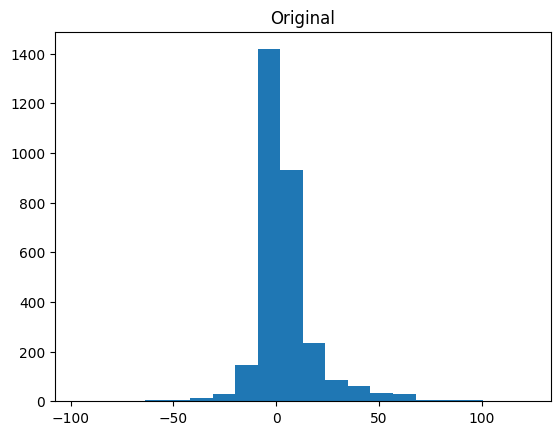

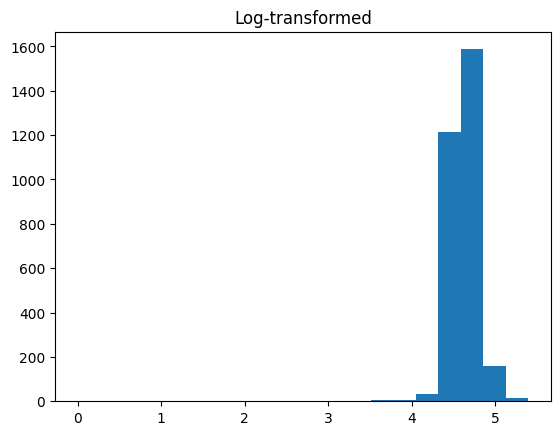

Log-tranformed
FCH4_L3.3_CUT_50_QCF0 was log-transformed


,FCH4_L3.3_CUT_50_QCF0,trt,SW_IN_POT,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,crop,timesince_soil_preparation,timesince_harvest,...,RECO_NT_CUT_50_gfXG_all_lag6h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_all_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_all_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_all_lag9h_roll9hsum,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,4.548914,1.0,0.000,0.000,5.333333,12.0,6.902486,9.815343,10.908412,45.779250,55.128997,42.768103,1.0,21.0,22.0,...,2.391322,2.429498,2.492754,2.499302,2.451650,0.013902,2.337490,35.587631,2.323588,35.573729,74.536042,33.250141,72.212455,85.021644,0
2023-11-08 02:15:00,4.614424,1.0,0.000,0.000,5.766667,16.0,7.089032,9.802778,11.114241,45.888163,55.228593,42.971042,1.0,21.0,22.0,...,2.288462,2.370560,2.341374,2.438065,2.448684,-0.211353,-0.129960,9.671769,0.081393,9.883123,49.292169,9.801730,49.210776,85.450285,4
2023-11-08 02:45:00,4.661232,1.0,0.000,0.000,5.666667,17.0,7.110031,9.717873,10.808778,45.900727,55.221686,43.013259,1.0,21.0,22.0,...,2.270913,2.354506,2.311898,2.416795,2.441974,-0.309957,-0.264579,5.744524,0.045378,6.054481,43.346336,6.009102,43.300958,81.336244,5
2023-11-08 03:15:00,4.548503,1.0,0.000,0.000,5.400000,18.0,7.258470,9.776045,10.794777,45.847515,55.221308,43.030472,1.0,21.0,22.0,...,2.257800,2.336118,2.289891,2.391322,2.429498,-0.865860,-0.851958,1.471630,0.013902,2.337490,35.587631,2.323588,35.573729,74.536042,6
2023-11-08 05:15:00,4.442036,1.0,0.000,0.000,5.033333,22.0,6.612354,9.996383,10.709149,45.973385,55.272922,43.440474,1.0,21.0,22.0,...,2.217741,2.258952,2.235550,2.288462,2.370560,-2.318292,-2.529646,-2.448253,-0.211353,-0.129960,9.671769,0.081393,9.883123,49.292169,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 13:45:00,4.694715,0.0,1144.190,0.034,20.080000,0.0,22.243332,18.496666,16.981111,48.234481,49.962609,45.515339,3.0,60.0,23.0,...,8.124284,8.190821,8.055241,8.189568,8.309095,185.687146,239.990377,238.983881,54.303231,53.296735,48.480995,-1.006496,-5.822236,-7.382366,27579
2025-06-04 15:15:00,4.696396,0.5,963.553,0.629,20.106667,0.0,21.989999,18.838889,17.015556,47.964659,49.906177,45.342369,3.0,60.0,23.0,...,8.239716,8.236522,8.000862,8.115498,8.198903,201.783742,307.452872,326.000477,105.669130,124.216734,118.285219,18.547604,12.616090,7.268258,27582
2025-06-04 15:45:00,4.329716,0.0,881.604,0.612,20.180000,0.0,21.791110,18.901111,17.095000,47.881311,49.867204,45.289633,3.0,60.0,23.0,...,8.312917,8.274623,8.025428,8.111731,8.190061,203.036039,345.544572,373.154404,142.508533,170.118365,165.183664,27.609832,22.675131,16.928158,27583


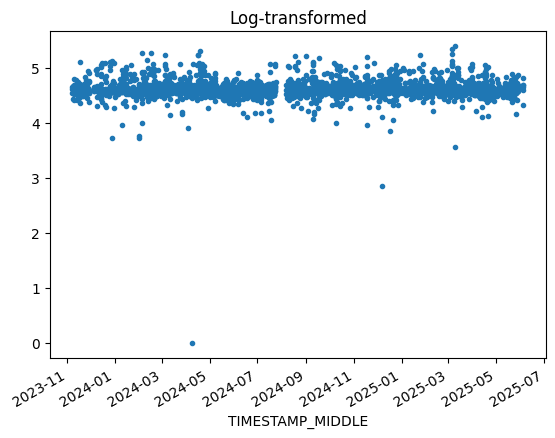

In [6]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

# Show histogram of non-tranformed and transformed TARGET
plt.hist(data[TARGET], bins=20)
plt.title('Original')
plt.show()
plt.hist(log_transform(data[TARGET]), bins=20)
plt.title('Log-transformed')
plt.show()

if LOG_TRANSFORM:
    print('Log-tranformed')
    data[TARGET] = log_transform(data[TARGET])
    print(f'{TARGET} was log-transformed')
    # Show log-transformed timeseries
    data[TARGET].plot(x_compat=True, style='.', title='Log-transformed');
else:
    print('\nLog-transformation of the target is not applied\n')

data

# CROSS-VAL SPLITS


Using time-blocks (6 records on average) splits for cross-validation



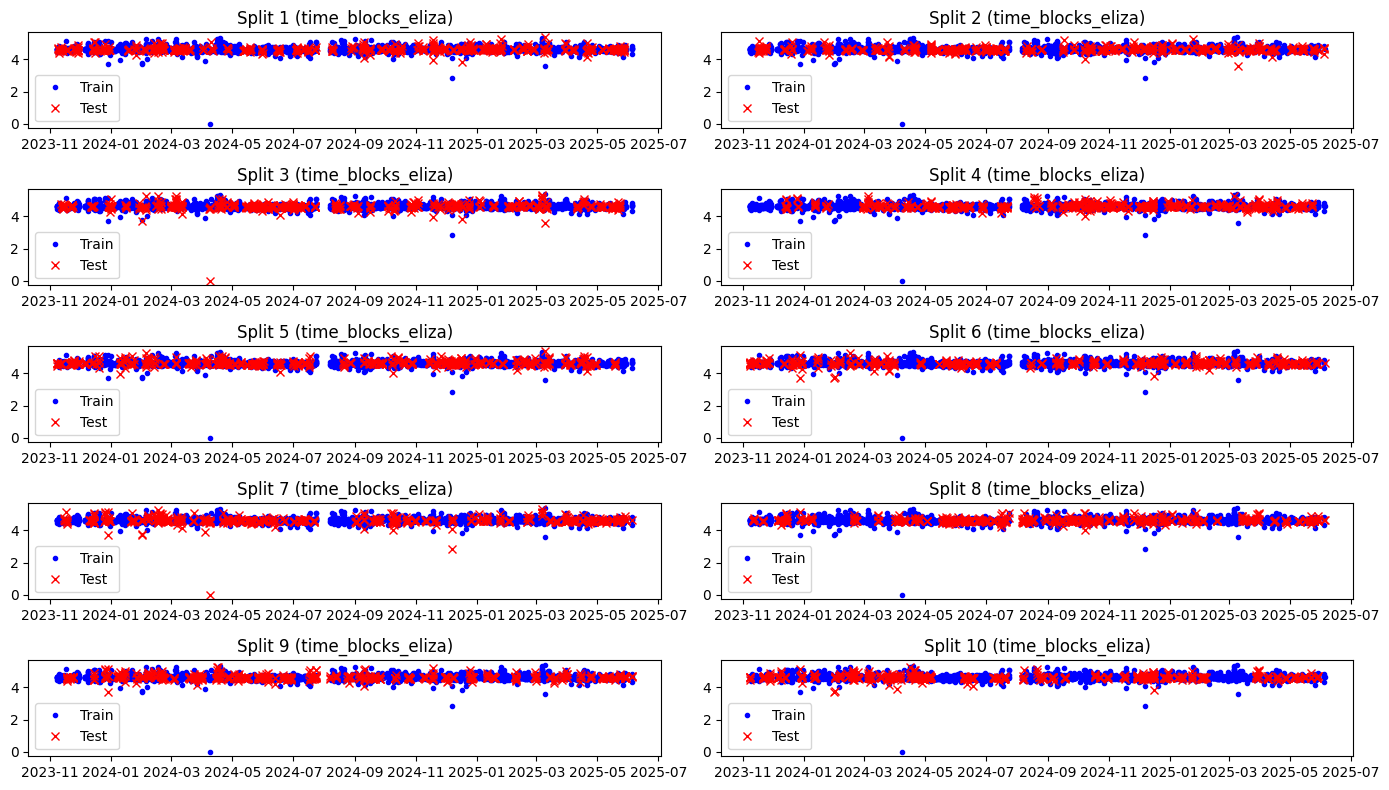

In [7]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
        print('\nUsing stratified random splits for cross-validation\n')
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)
        print('\nUsing stratified kfold splits for cross-validation\n')

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    block_size = 6 
    print(f'\nUsing time-blocks ({block_size} records on average) splits for cross-validation\n')
    def create_splits(X, y, n_folds, split=0.2, mean_block=block_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# FEATURE SELECTION

## Permutation importance

In [8]:
N_REPEATS = 5
N_RANDOMS = 10
def permutation_importance_selection(X, y, n_repeats=N_REPEATS, n_randoms=N_RANDOMS):
    iteration = 0
    # Generate random features ONCE and keep them throughout the iterations
    np.random.seed(42)  # Ensures reproducibility
    for i in range(n_randoms):
        X[f'random_{i}'] = np.random.permutation(len(X))

    while True:
        iteration += 1
        print(f"Iteration {iteration}: Starting with {X.shape[1] - n_randoms} features")

        model = RandomForestRegressor(n_estimators=100, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1) \
            if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        importance_scores, rmse_scores, r2_scores = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X.iloc[train_idx], y.iloc[train_idx], X.iloc[test_idx], y.iloc[test_idx]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)

            perm_importance = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=42, n_jobs=-1)
            importance_scores.append(perm_importance.importances_mean)
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))

        mean_importance = np.mean(importance_scores, axis=0)
        threshold = np.mean(mean_importance[-n_randoms:])  # Use average of random features as threshold
        
        to_remove = [col for col in X.columns if mean_importance[X.columns.get_loc(col)] < threshold and not col.startswith('random_')]
        to_keep = [col for col in X.columns if col not in to_remove]
        print(f"Iteration {iteration}: Removed {len(to_remove)} features, RMSE: {np.mean(rmse_scores):.4f}, R²: {np.mean(r2_scores):.4f}")
        
        if len(to_remove) == 0:
            break  # Stop when no features are removed

        X = X[to_keep].copy()

    # Remove random features from final selection
    to_keep = [col for col in to_keep if not col.startswith('random_')]
    return to_keep

if PERMUTATION_SEL:
    to_keep = permutation_importance_selection(data.drop(columns=[TARGET]), data[TARGET])
    data = data[to_keep + [TARGET]]
    to_keep
else:
    print('Permutation importance based feature removal is not applied')

Permutation importance based feature removal is not applied


## Recursive feature elimination

Iteration 1: Remaining features: 192, Removed: ts_0.15_gfXG_lag3h_roll6hmean, RMSE: 16.2728, R²: -0.1148
Iteration 2: Remaining features: 191, Removed: ts_0.3_gfXG_lag6h_roll3hmean, RMSE: 16.2817, R²: -0.1160
Iteration 3: Remaining features: 190, Removed: crop, RMSE: 16.3360, R²: -0.1239
Iteration 4: Remaining features: 189, Removed: ts_0.3_gfXG_lag3h_roll6hmean, RMSE: 16.3360, R²: -0.1239
Iteration 5: Remaining features: 188, Removed: prec_lag9h, RMSE: 16.3111, R²: -0.1195
Iteration 6: Remaining features: 187, Removed: ts_0.3_gfXG_lag6h_roll9hmean, RMSE: 16.2055, R²: -0.1054
Iteration 7: Remaining features: 186, Removed: ts_0.05_gfXG_lag3h_roll6hmean, RMSE: 16.2195, R²: -0.1070
Iteration 8: Remaining features: 185, Removed: prec_lag9h_roll3hsum, RMSE: 16.2598, R²: -0.1125
Iteration 9: Remaining features: 184, Removed: ts_0.3_gfXG_roll6hmean, RMSE: 16.2610, R²: -0.1127
Iteration 10: Remaining features: 183, Removed: ts_0.3_gfXG, RMSE: 16.2761, R²: -0.1146
Iteration 11: Remaining featur

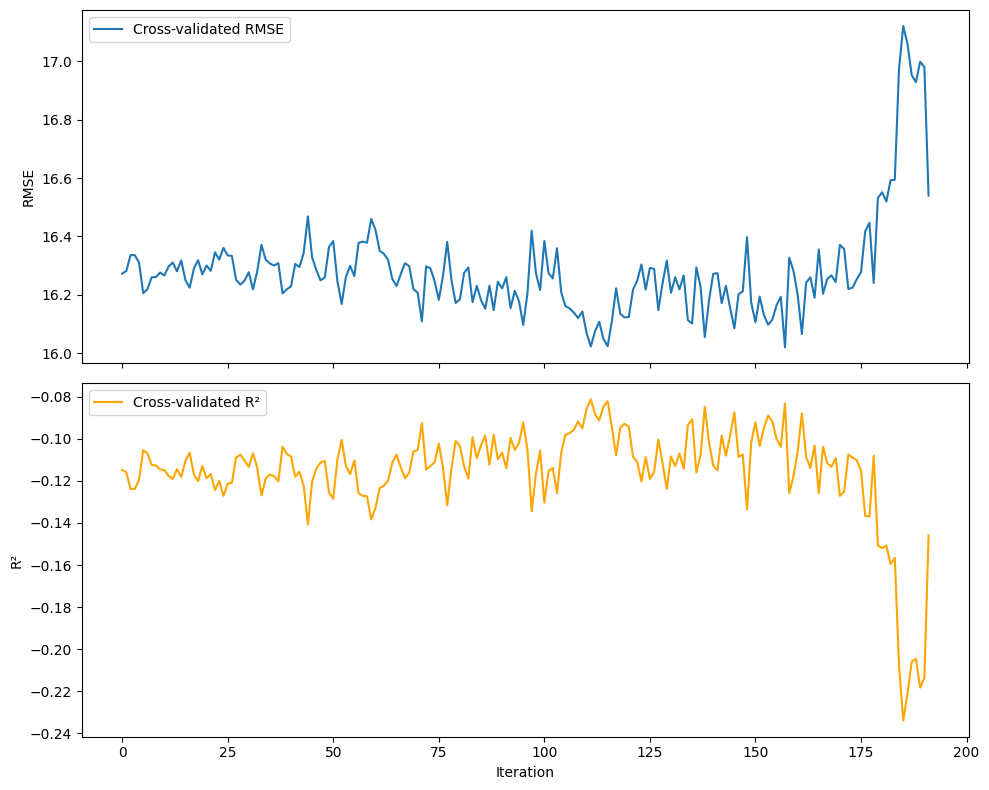


Best feature set found at iteration 158:
Selected Features: ['timesince_prec', 'ta_lag6h', 'ta_roll6hmean', 'ts_0.05_gfXG_roll6hmean', 'ts_0.3_gfXG_roll9hmean', 'ta_lag3h_roll3hmean', 'ta_lag9h_roll6hmean', 'ts_0.05_gfXG_lag3h_roll3hmean', 'ts_0.05_gfXG_lag9h_roll9hmean', 'ts_0.15_gfXG_lag6h_roll6hmean', 'wfps_0.15_gfXG_lag6h_roll9hmean', 'wfps_0.15_gfXG_lag9h_roll9hmean', 'wfps_0.3_gfXG_lag6h_roll3hmean', 'wfps_0.3_gfXG_lag9h_roll6hmean', 'wfps_0.3_gfXG_lag9h_roll9hmean', 'ts_0.05_gfXG_diff12h', 'ts_0.15_gfXG_diff6h', 'ts_0.3_gfXG_diff6h', 'ts_0.3_gfXG_diff24h', 'wfps_0.05_gfXG_diff12h', 'wfps_0.3_gfXG_diff6h', 'wfps_0.3_gfXG_diff12h', 'NEE_L3.3_CUT_50_QCF0_gfXGBoost_all', 'RECO_NT_CUT_50_gfXG_all', 'GPP_NT_CUT_50_gfXG_all', 'n_decay_linear', 'n_decay_logistic', 'n_decay_exponential', 'n_decay_lognormal', 'n_decay_timed', 'GPP_NT_CUT_50_gfXG_all_lag6h', 'RECO_NT_CUT_50_gfXG_all_roll3hmean', 'GPP_NT_CUT_50_gfXG_all_roll3hsum', 'RECO_NT_CUT_50_gfXG_all_lag9h_roll6hmean', 'GPP_NT_CUT_50

In [9]:
def rfe_selection(X, y, cross_val_splits):
    performance = []
    iteration = 0
    features = list(X.columns)
    feature_removal_order = []  # Store removed features and their iteration index

    while len(features) > 1:
        iteration += 1
        rmse_scores, r2_scores, importances = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X[features].iloc[train_idx], y.iloc[train_idx], X[features].iloc[test_idx], y.iloc[test_idx]
            model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)
            
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))
            importances.append(model.feature_importances_)

        mean_rmse = np.mean(rmse_scores)
        mean_r2 = np.mean(r2_scores)
        performance.append((features.copy(), mean_rmse, mean_r2))

        mean_importances = np.mean(importances, axis=0)
        least_important_index = np.argmin(mean_importances)
        least_important_feature = features.pop(least_important_index)

        # Store the removed feature with its iteration index
        feature_removal_order.append((least_important_feature, iteration))

        print(f"Iteration {iteration}: Remaining features: {len(features)}, Removed: {least_important_feature}, RMSE: {mean_rmse:.4f}, R²: {mean_r2:.4f}")

    # Extract RMSE and R² values
    rmse_values = [score[1] for score in performance]
    r2_values = [score[2] for score in performance]

    # Plot RMSE and R² over iterations
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    axs[0].plot(range(len(performance)), rmse_values, label="Cross-validated RMSE")
    axs[0].set_ylabel("RMSE")
    axs[0].legend()

    axs[1].plot(range(len(performance)), r2_values, label="Cross-validated R²", color="orange")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("R²")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Select best feature set by minimizing both R² and RMSE and penlizing larger feature sets
    # Normalize RMSE and R²
    norm_rmse = (np.array(rmse_values) - min(rmse_values)) / (max(rmse_values) - min(rmse_values))
    norm_r2 = (np.array(r2_values) - min(r2_values)) / (max(r2_values) - min(r2_values))
    # Set weights for normalized metrics
    w_rmse, w_r2, w_penalty = 0.5, 0.5, 0.001  # Adjust w_penalty as needed
    # Calculate composite scores with normalized metrics and feature count penalty
    composite_scores = [
        (performance[i][0], # Features
         i + 1, # Iteration number
        w_rmse * norm_rmse[i] + w_r2 * (1 - norm_r2[i]) + w_penalty * len(performance[i][0])  # Composite score
        )  
        for i in range(len(performance))
    ]

    # Find the feature subset with the best (lowest) composite score
    best_features, best_iteration, _ = min(composite_scores, key=lambda x: x[2])

    # Add the final remaining feature
    feature_removal_order.append((features[0], iteration + 1))

    # Rank features based on removal order
    feature_ranking = [feature for feature, _ in sorted(feature_removal_order, key=lambda x: x[1], reverse=True)]

    # Print the best feature set details
    print(f"\nBest feature set found at iteration {best_iteration}:")
    print(f"Selected Features: {best_features}")
    print(f"Performance - RMSE: {rmse_values[best_iteration-1]:.4f}, R²: {r2_values[best_iteration-1]:.4f}")

    return best_features, feature_ranking

if RFE_SEL:
    selected_features, ranked_features = rfe_selection(data.drop(columns=[TARGET]), data[TARGET], cross_val_splits= cross_val_splits)
    # Update the main dataframe
    data = data[selected_features + [TARGET]]
else:
    print('Recursive Feature Elimination is not applied')

# EXPORT 

In [10]:
filename = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in selected_features:
        f.write(f"{item}\n")

filename = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in ranked_features:
        f.write(f"{item}\n")

# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-11-04 16:02:27
